# Ljungqvist & Sargent (2018), Chapter 3 --- Dynamic Programming

Companion notebook to `ls_solutions_ch03.pdf`. Chapter 3 has a single end-of-chapter exercise,
**Exercise 3.1 (Howard's policy iteration algorithm)**, p. 114. The exercise is analytical; this
notebook checks every analytical claim by an independent numerical route and then solves a
discretised version of the same model by value iteration (VFI) and policy iteration (PFI).

Model: maximise $E_0\sum_{t=0}^\infty \beta^t\ln c_t$ s.t. $c_t+k_{t+1}\le A k_t^\alpha\theta_t$,
$\ln\theta_t\sim$ i.i.d. $N(0,\sigma^2)$. Write $y=Ak^\alpha\theta$ for output.

Parameters are not given in the book; we use $A=1$, $\alpha=0.33$, $\beta=0.95$, $\sigma=0.2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

plt.rcParams.update({"pdf.fonttype": 42, "font.size": 10})  # TrueType, never Type 3
FIG = "fig/"

A, alpha, beta, sigma = 1.0, 0.33, 0.95, 0.2
ab = alpha * beta
print("alpha*beta =", ab)

alpha*beta = 0.3135


## Exercise 3.1 --- Step 1: the value of an arbitrary policy $k'=h\,y$

Closed form derived in the PDF (eq. (3)):
$$J_h(k,\theta)=\frac{\ln(1-h)}{1-\beta}+\frac{\beta(\ln A+\alpha\ln h)}{(1-\beta)(1-\alpha\beta)}+\frac{\ln(Ak^\alpha\theta)}{1-\alpha\beta}.$$

Independent routes: (i) iterate the exact mean of $\ln y_t$, $m_{t+1}=\ln A+\alpha\ln h+\alpha m_t$,
and sum $\sum_t\beta^t[\ln(1-h)+m_t]$ to $T=2000$; (ii) Monte Carlo over simulated $\theta$ paths.

In [2]:
def J_closed(h, k, th):
    return (np.log(1 - h) / (1 - beta)
            + beta * (np.log(A) + alpha * np.log(h)) / ((1 - beta) * (1 - ab))
            + np.log(A * k**alpha * th) / (1 - ab))

def J_recursion(h, k, th, T=2000):
    m, tot = np.log(A * k**alpha * th), 0.0
    for t in range(T):
        tot += beta**t * (np.log(1 - h) + m)
        m = np.log(A) + alpha * np.log(h) + alpha * m
    return tot

def J_montecarlo(h, k, th, T=600, N=20000, seed=0):
    rng = np.random.default_rng(seed)
    lny = np.full(N, np.log(A * k**alpha * th))
    tot = np.zeros(N)
    for t in range(T):
        tot += beta**t * (np.log(1 - h) + lny)
        lny = np.log(A) + alpha * (np.log(h) + lny) + sigma * rng.standard_normal(N)
    return tot.mean(), tot.std() / np.sqrt(N)

for h0 in (0.1, 0.5, 0.9):
    for k, th in ((0.2, 1.0), (1.0, 0.8)):
        jc, jr = J_closed(h0, k, th), J_recursion(h0, k, th)
        jm, se = J_montecarlo(h0, k, th)
        assert abs(jc - jr) < 1e-9
        assert abs(jc - jm) < 5 * se
        print(f"h0={h0:.1f} k={k:.1f} th={th:.1f}: closed={jc:9.4f} recursion={jr:9.4f} MC={jm:9.4f} (se {se:.3f})")

h0=0.1 k=0.2 th=1.0: closed= -23.9110 recursion= -23.9110 MC= -23.9069 (se 0.006)
h0=0.1 k=1.0 th=0.8: closed= -23.4624 recursion= -23.4624 MC= -23.4583 (se 0.006)


h0=0.5 k=0.2 th=1.0: closed= -20.9673 recursion= -20.9673 MC= -20.9632 (se 0.006)
h0=0.5 k=1.0 th=0.8: closed= -20.5187 recursion= -20.5187 MC= -20.5146 (se 0.006)


h0=0.9 k=0.2 th=1.0: closed= -47.7876 recursion= -47.7876 MC= -47.7835 (se 0.006)
h0=0.9 k=1.0 th=0.8: closed= -47.3390 recursion= -47.3390 MC= -47.3349 (se 0.006)


## Exercise 3.1 --- Step 2: the improvement step gives $h_1=\alpha\beta$ for every $h_0$

Numerically maximise $\ln(y-k')+\beta E\,J_{h_0}(k',\theta')$ over $k'\in(0,y)$, computing the
expectation over $\theta'$ with 20-node Gauss--Hermite quadrature (so $E\ln\theta'=0$ is *not*
imposed by hand). The analytical claim is $k'/y=\alpha\beta$ regardless of $h_0$, $k$ and $\theta$.

In [3]:
gh_x, gh_w = np.polynomial.hermite_e.hermegauss(20)   # probabilists' Hermite: weight exp(-x^2/2)
gh_w = gh_w / gh_w.sum()
theta_nodes = np.exp(sigma * gh_x)

def improve(h0, k, th):
    y = A * k**alpha * th
    obj = lambda kp: -(np.log(y - kp) + beta * gh_w @ J_closed(h0, kp, theta_nodes))
    res = minimize_scalar(obj, bounds=(1e-10 * y, y * (1 - 1e-10)), method="bounded",
                          options={"xatol": 1e-13 * y})
    return res.x / y

rows = []
for h0 in (0.05, 0.2, 0.5, 0.8, 0.95):
    h1s = [improve(h0, k, th) for k in (0.05, 0.3, 1.0) for th in (0.7, 1.0, 1.4)]
    rows.append((h0, min(h1s), max(h1s)))
    assert np.allclose(h1s, ab, atol=1e-7)
    h2 = improve(np.mean(h1s), 0.3, 1.0)            # a second improvement step changes nothing
    assert abs(h2 - ab) < 1e-7
for r in rows:
    print("h0 = %.2f -> h1 in [%.8f, %.8f]" % r)
print("alpha*beta   =", ab)

h0 = 0.05 -> h1 in [0.31349997, 0.31350002]
h0 = 0.20 -> h1 in [0.31349997, 0.31350002]
h0 = 0.50 -> h1 in [0.31349997, 0.31350002]
h0 = 0.80 -> h1 in [0.31349997, 0.31350001]
h0 = 0.95 -> h1 in [0.31349999, 0.31350002]
alpha*beta   = 0.3135


## Exercise 3.1 --- Step 3: $J_{\alpha\beta}$ solves the Bellman equation

Bellman residual $\max_{k'}\{\ln(y-k')+\beta E J_{\alpha\beta}(k',\theta')\}-J_{\alpha\beta}(k,\theta)$
on a grid of states, with the max and the expectation computed numerically.

In [4]:
def TJ(h, k, th):
    y = A * k**alpha * th
    obj = lambda kp: -(np.log(y - kp) + beta * gh_w @ J_closed(h, kp, theta_nodes))
    return -minimize_scalar(obj, bounds=(1e-10 * y, y * (1 - 1e-10)), method="bounded",
                            options={"xatol": 1e-13 * y}).fun

resid = max(abs(TJ(ab, k, th) - J_closed(ab, k, th))
            for k in np.linspace(0.05, 1.5, 8) for th in (0.6, 1.0, 1.6))
print("max |T J_ab - J_ab| =", resid)
assert resid < 1e-9
# and for comparison: J_h for h != ab is NOT a fixed point (T J_h > J_h, the improvement is strict)
print("T J_0.5 - J_0.5 at k=0.3, th=1:", TJ(0.5, 0.3, 1.0) - J_closed(0.5, 0.3, 1.0))

max |T J_ab - J_ab| = 7.105427357601002e-15
T J_0.5 - J_0.5 at k=0.3, th=1: 0.10382326957902066


## Contrast: value iteration from $v_0=0$

Guess $v_j=e_j+f_j\ln y$; the FOC gives $k'=\frac{\alpha\beta f_j}{1+\alpha\beta f_j}y$ and
$f_{j+1}=1+\alpha\beta f_j$, $f_0=0$. Hence the policy after $j$ Bellman iterations is
$h^{VFI}_j=\alpha\beta\,\frac{1-(\alpha\beta)^{j-1}}{1-(\alpha\beta)^{j}}$ (with $h^{VFI}_1=0$):
geometric convergence at rate $\alpha\beta$, against exact convergence in one step for Howard.
Independent check: iterate the Bellman operator numerically on the coefficients.

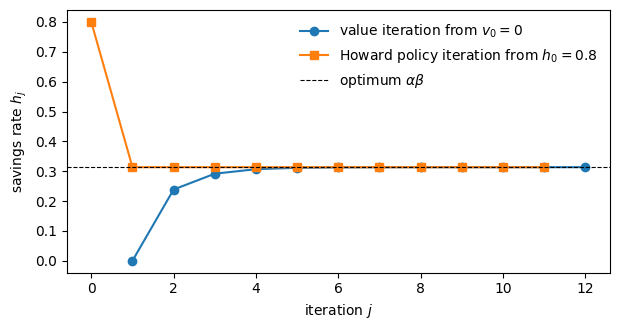

[0.       0.238675 0.291675 0.306804 0.311415 0.312848 0.313296 0.313436
 0.31348  0.313494 0.313498 0.313499]


In [5]:
J = 12
f, h_vfi_num = 0.0, []
for j in range(1, J + 1):
    y = 1.0   # policy share is state-independent; compute it at y=1 by numerical maximisation
    obj = lambda kp: -(np.log(y - kp) + beta * f * alpha * np.log(kp))
    s = minimize_scalar(obj, bounds=(0, 1), method="bounded", options={"xatol": 1e-14}).x if f > 0 else 0.0
    h_vfi_num.append(s)
    f = 1 + ab * f
j = np.arange(1, J + 1)
h_vfi = ab * (1 - ab**(j - 1)) / (1 - ab**j)
assert np.allclose(h_vfi, h_vfi_num, atol=1e-8)

h_pfi = [0.8] + [ab] * (J - 1)   # Howard from h0 = 0.8
fig, ax = plt.subplots(figsize=(6.3, 3.4))
ax.plot(j, h_vfi, "o-", label="value iteration from $v_0=0$")
ax.plot(np.arange(0, J), h_pfi, "s-", label="Howard policy iteration from $h_0=0.8$")
ax.axhline(ab, color="k", lw=0.8, ls="--", label=r"optimum $\alpha\beta$")
ax.set_xlabel("iteration $j$"); ax.set_ylabel("savings rate $h_j$")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(FIG + "ls03_policy_iteration.pdf"); plt.show()
print(np.round(h_vfi, 6))

## Discretised version: VFI vs PFI on a grid

Capital on a 250-point geometric grid over $[0.2\bar k,4\bar k]$ ($\bar k$ the deterministic steady state), $\theta$ on 7 Gauss--Hermite nodes (symmetric in $\ln\theta$, so
$E\ln\theta'=0$ still holds and the closed-form $V=J_{\alpha\beta}$ is still the exact benchmark).
Because $\theta$ is i.i.d., $EV(k')=\sum_s w_s V(k',\theta_s)$. PFI evaluates each policy by
solving the linear system $V=R_h+\beta P_h V$.

On a grid the one-step result need not hold exactly: the rounded policy $k'\approx h_0y$ does not give a value function exactly linear in $\ln y$, so the first improvement lands near, not on, $\alpha\beta$. The cell prints how far.

In [6]:
nk, ns = 250, 7
kbar = (ab * A) ** (1 / (1 - alpha))
kgrid = np.geomspace(0.2 * kbar, 4 * kbar, nk)
x, w = np.polynomial.hermite_e.hermegauss(ns); w = w / w.sum(); th = np.exp(sigma * x)
Y = A * kgrid[:, None]**alpha * th[None, :]                 # (nk, ns)
C = Y[:, :, None] - kgrid[None, None, :]                   # (nk, ns, nk')
R = np.where(C > 0, np.log(np.maximum(C, 1e-300)), -np.inf)

def greedy(V):
    EV = V @ w                                             # (nk',)
    Q = R + beta * EV[None, None, :]
    return Q.argmax(2), Q.max(2)

# VFI
V = np.zeros((nk, ns)); it_vfi = 0
while True:
    it_vfi += 1
    pol, Vn = greedy(V)
    if np.max(abs(Vn - V)) < 1e-10: V_vfi, pol_vfi = Vn, pol; break
    V = Vn

# PFI (Howard), start from h0 = 0.25 mapped to the grid (0.25*y stays inside the grid for every state)
pol = np.abs(kgrid[None, None, :] - 0.25 * Y[:, :, None]).argmin(2); it_pfi = 0; changes = []; share_err = []
inner = (Y > kgrid[0] / ab) & (Y < kgrid[-1] / ab)          # states whose optimum is inside the grid
n = nk * ns
while True:
    it_pfi += 1
    Rh = np.take_along_axis(R, pol[:, :, None], 2)[:, :, 0].ravel()
    P = np.zeros((n, n))
    rows = np.arange(n); cols_k = pol.ravel()
    for s in range(ns):
        P[rows, cols_k * ns + s] += w[s]
    Vh = np.linalg.solve(np.eye(n) - beta * P, Rh).reshape(nk, ns)
    newpol, _ = greedy(Vh)
    changes.append(int((newpol != pol).sum()))
    share_err.append(np.abs(kgrid[newpol] / Y - ab)[inner].max())
    if np.array_equal(newpol, pol): V_pfi, pol_pfi = Vh, pol; break
    pol = newpol

print("VFI iterations:", it_vfi, "  PFI iterations (incl. final check):", it_pfi)
print("grid points (of %d) whose policy changes at each PFI step:" % n, changes)
print("max |k'/y - alpha*beta| after each PFI step:", np.round(share_err, 4))
assert np.array_equal(pol_vfi, pol_pfi)
assert np.max(abs(V_vfi - V_pfi)) < 1e-7
share = kgrid[pol_pfi] / Y
print("grid savings share on interior states: min %.4f max %.4f (alpha*beta = %.4f)"
      % (share[inner].min(), share[inner].max(), ab))
assert np.max(abs(share[inner] - ab)) < 0.02
Vtrue = J_closed(ab, kgrid[:, None], th[None, :])
err = np.max(abs(V_pfi - Vtrue)[kgrid > kgrid[0] * 1.5])
print("max |V_grid - V_closed| away from the lower edge:", err)
assert err < 0.02

VFI iterations: 450   PFI iterations (incl. final check): 6
grid points (of 1750) whose policy changes at each PFI step: [1750, 1059, 349, 90, 8, 0]
max |k'/y - alpha*beta| after each PFI step: [0.0125 0.0058 0.0028 0.0022 0.0021 0.0021]
grid savings share on interior states: min 0.3114 max 0.3156 (alpha*beta = 0.3135)
max |V_grid - V_closed| away from the lower edge: 8.922071005201815e-05


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


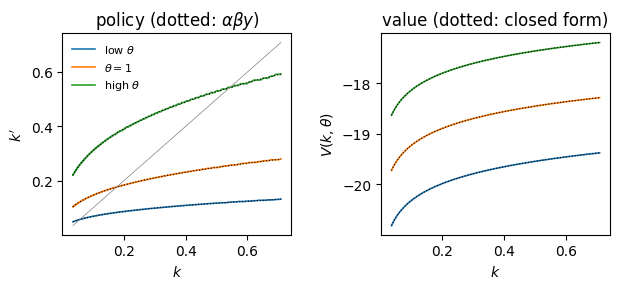

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(6.3, 3.0))
for s, lab in ((0, r"low $\theta$"), (ns // 2, r"$\theta=1$"), (ns - 1, r"high $\theta$")):
    axs[0].plot(kgrid, kgrid[pol_pfi[:, s]], lw=1.2, label=lab)
    axs[0].plot(kgrid, ab * Y[:, s], "k:", lw=0.8)
    axs[1].plot(kgrid, V_pfi[:, s], lw=1.2)
    axs[1].plot(kgrid, Vtrue[:, s], "k:", lw=0.8)
axs[0].plot(kgrid, kgrid, color="gray", lw=0.5)
axs[0].set_xlabel("$k$"); axs[0].set_ylabel("$k'$"); axs[0].set_title("policy (dotted: $\\alpha\\beta y$)")
axs[1].set_xlabel("$k$"); axs[1].set_ylabel("$V(k,\\theta)$"); axs[1].set_title("value (dotted: closed form)")
axs[0].legend(frameon=False, fontsize=8); fig.tight_layout()
fig.savefig(FIG + "ls03_discrete.pdf"); plt.show()